# 01 - Data Cleaning & Integration Pipeline (Deliverable A)

**Team Adwa** - Qiyas / IADE Training Program, Addis Ababa University - Ethiopian Smallholder Crop-Yield Challenge

Turns the three raw exports into one trustworthy modeling table and proves it is trustworthy.
Every number in this notebook is produced by code; the same pipeline runs on the test file using
statistics fit on the train file only (Rule 6).

| Section | Deliverable |
|---|---|
| A1 | Cleaning log (all three files) |
| A2 | Key standardisation proof (region, crop_type) |
| A3 | Join map & diagram |
| A4 | Join audit (match rates, row counts, window coverage) |
| A5 | Join proof for 3 specific plots |
| A6 | Feature engineering table |
| A7 | Integrity checks (PASS/FAIL) |
| A8 | Master tables & data dictionary |

Run order: `01 -> 02 -> 03 -> 04`, executed from the project root.

In [1]:
%matplotlib inline
from pathlib import Path
import os, sys

# Always work from the project root, so every path below stays relative (Rule 6.3).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)

from src import cleaning as cl
from src import features as ft
print("project root:", Path.cwd())

project root: C:\Users\CISCO\Desktop\er\team_adwa


## Load the raw exports (never edited - Rule 6.3)

In [2]:
raw = {k: cl.read_raw(k) for k in ["train", "test", "weather", "prices"]}
for k, df in raw.items():
    print(f"{k:8s} rows={len(df):6d}  cols={df.shape[1]:2d}  {cl.RAW_FILES[k]}")
raw["train"].head(3)

train    rows= 15090  cols=15  data/raw/crop_yield_train.csv
test     rows=  3750  cols=14  data/raw/crop_yield_leaderboard_test.csv
weather  rows=   232  cols= 6  data/raw/regional_weather.csv
prices   rows=   100  cols= 4  data/raw/market_prices.csv


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,pest_disease_flag,soil_quality_index,labor_days_per_ha,distance_to_market_km,yield_tons_per_ha
0,PLOT-000339,OROMIA,barley,2024,Aug,2697.817349,1157.403560,0.867604,29.393684,0,1,0.399408,42.678102,8.573726,2.209711
1,PLOT-007457,Amhara,Maize,2023,Jun,1523.350141,897.420122,1.099197,16.843992,1,0,0.314488,45.370495,19.928302,3.363254
2,PLOT-006092,OROMIA,wheat,2024,Feb,2389.441948,1119.155741,0.811309,41.015144,0,0,0.812596,52.846126,8.961797,3.560614


## A1 - Cleaning log

One row per issue: file, columns, issue type, rows affected (count and %), the fix and why.
Coverage: **plot file** (labels, -999 sentinels, blanks, outliers), **weather file** (labels,
duplicate keys, missing readings), **price file** (labels, unit mix-up, missing prices).

In [3]:
train_clean, train_stats, log_train = cl.clean_plots(raw["train"], "crop_yield_train.csv")
# test goes through the SAME code with statistics fit on train only (Rule 6)
test_clean, _, log_test = cl.clean_plots(raw["test"], "crop_yield_leaderboard_test.csv",
                                         stats=train_stats)
weather_clean, log_weather = cl.clean_weather(raw["weather"])
prices_clean, log_prices = cl.clean_prices(raw["prices"])

log = cl.CleaningLog()
for part in (log_train, log_test, log_weather, log_prices):
    log.extend(part)
cleaning_log = log.to_frame()

print("issue rows per file:")
print(cleaning_log.groupby("file").size().to_string())
print()
print("raw rows affected per file (one row can carry several issues):")
print(cleaning_log.groupby("file")["rows_affected"].sum().to_string())
cleaning_log

issue rows per file:
file
crop_yield_leaderboard_test.csv    12
crop_yield_train.csv               12
market_prices.csv                   3
regional_weather.csv                4

raw rows affected per file (one row can carry several issues):
file
crop_yield_leaderboard_test.csv    2010
crop_yield_train.csv               8310
market_prices.csv                    30
regional_weather.csv                 65


,file,columns,issue_type,rows_affected,pct_of_rows,fix_applied,why
0,crop_yield_train.csv,region,"inconsistent region labels (upper/lower case, ...",2363,15.66,str.strip + case fold + alias map to the canon...,region/crop/month are join keys for weather an...
1,crop_yield_train.csv,crop_type,"inconsistent crop labels (upper/lower case, pa...",2982,19.76,str.strip + case fold + alias map to the canon...,region/crop/month are join keys for weather an...
2,crop_yield_train.csv,pest_disease_flag,missing-value sentinel -999 stored as a real n...,300,1.99,"replaced -999 with NaN, then imputed with the ...",as written -999 would be read as a measurement...
3,crop_yield_train.csv,labor_days_per_ha,missing-value sentinel -999 stored as a real n...,488,3.23,"replaced -999 with NaN, then imputed with the ...",as written -999 would be read as a measurement...
4,crop_yield_train.csv,rainfall_mm_season,blank / missing values in the raw export,449,2.98,imputed with the train-fitted median (or mode ...,rows must be kept - the leaderboard scores eve...
5,crop_yield_train.csv,fertilizer_kg_per_ha,blank / missing values in the raw export,748,4.96,imputed with the train-fitted median (or mode ...,rows must be kept - the leaderboard scores eve...
6,crop_yield_train.csv,soil_quality_index,blank / missing values in the raw export,608,4.03,imputed with the train-fitted median (or mode ...,rows must be kept - the leaderboard scores eve...
7,crop_yield_train.csv,rainfall_mm_season,implausible extreme value (heavy tail),74,0.49,capped at the train 99.5% quantile = 1485.64,"a handful of 3,800 mm / 900 kg/ha / 60 ha repo..."
8,crop_yield_train.csv,farm_size_ha,implausible extreme value (heavy tail),76,0.50,capped at the train 99.5% quantile = 5.44,"a handful of 3,800 mm / 900 kg/ha / 60 ha repo..."
9,crop_yield_train.csv,fertilizer_kg_per_ha,implausible extreme value (heavy tail),72,0.48,capped at the train 99.5% quantile = 163.28,"a handful of 3,800 mm / 900 kg/ha / 60 ha repo..."


In [4]:
# Statistics fit on the TRAIN file and then applied unchanged to the test file (Rule 6)
stats_table = pd.DataFrame(
    [{"group": "imputation", "column": k, "value": round(v, 3),
      "used_for": "blank / -999 values in train and test"}
     for k, v in train_stats["median"].items()]
    + [{"group": "imputation", "column": k, "value": v,
        "used_for": "mode of a binary flag"}
       for k, v in train_stats["mode"].items()]
    + [{"group": "outlier cap", "column": k, "value": round(v, 3),
        "used_for": f"values above the train {train_stats['quantile']:.1%} quantile are capped"}
       for k, v in train_stats["caps"].items()])
print(f"fit on {train_stats['fit_rows']:,} training rows, never on the test file")
stats_table

fit on 15,090 training rows, never on the test file


,group,column,value,used_for
0,imputation,rainfall_mm_season,848.764,blank / -999 values in train and test
1,imputation,fertilizer_kg_per_ha,33.827,blank / -999 values in train and test
2,imputation,soil_quality_index,0.565,blank / -999 values in train and test
3,imputation,labor_days_per_ha,45.035,blank / -999 values in train and test
4,imputation,pest_disease_flag,0.000,mode of a binary flag
5,outlier cap,rainfall_mm_season,1485.644,values above the train 99.5% quantile are capped
6,outlier cap,farm_size_ha,5.439,values above the train 99.5% quantile are capped
7,outlier cap,fertilizer_kg_per_ha,163.279,values above the train 99.5% quantile are capped
8,outlier cap,labor_days_per_ha,83.982,values above the train 99.5% quantile are capped
9,outlier cap,distance_to_market_km,62.657,values above the train 99.5% quantile are capped


## A2 - Key standardisation proof

Unique values **before** cleaning (raw) and **after** cleaning for `region` (all three tables)
and `crop_type` (plot and price tables). After cleaning every table must carry the identical label set.

In [5]:
def uniq(s):
    return sorted(pd.unique(s.astype(str)))

rows = []
for table, df_raw, df_clean, col in [
    ("plot (train)", raw["train"], train_clean, "region"),
    ("plot (test)", raw["test"], test_clean, "region"),
    ("weather", raw["weather"], weather_clean, "region"),
    ("price", raw["prices"], prices_clean, "region"),
    ("plot (train)", raw["train"], train_clean, "crop_type"),
    ("plot (test)", raw["test"], test_clean, "crop_type"),
    ("price", raw["prices"], prices_clean, "crop_type"),
]:
    before, after = uniq(df_raw[col]), uniq(df_clean[col])
    canonical = set(cl.REGIONS) if col == "region" else set(cl.CROPS)
    rows.append({"table": table, "column": col, "n_before": len(before),
                 "unique_before": ", ".join(repr(v) for v in before),
                 "n_after": len(after), "unique_after": ", ".join(after),
                 "matches_canonical_set": "yes" if set(after) == canonical else "NO"})
key_proof = pd.DataFrame(rows)
key_proof

,table,column,n_before,unique_before,n_after,unique_after,matches_canonical_set
0,plot (train),region,19,"'AMHARA', 'Amhara', 'Amhara ', 'OROMIA', 'Orom...",5,"Amhara, Oromia, SNNPR, Somali, Tigray",yes
1,plot (test),region,19,"'AMHARA', 'Amhara', 'Amhara ', 'OROMIA', 'Orom...",5,"Amhara, Oromia, SNNPR, Somali, Tigray",yes
2,weather,region,20,"'AMH', 'Amhara', 'Amhara ', 'ORO', 'Oromia', '...",5,"Amhara, Oromia, SNNPR, Somali, Tigray",yes
3,price,region,5,"'Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray'",5,"Amhara, Oromia, SNNPR, Somali, Tigray",yes
4,plot (train),crop_type,21,"' barley ', ' maize ', ' sorghum ', ' teff ', ...",5,"barley, maize, sorghum, teff, wheat",yes
5,plot (test),crop_type,21,"' barley ', ' maize ', ' sorghum ', ' teff ', ...",5,"barley, maize, sorghum, teff, wheat",yes
6,price,crop_type,14,"' barley ', ' maize ', ' sorghum ', ' teff ', ...",5,"barley, maize, sorghum, teff, wheat",yes


In [6]:
# A2 assertions: identical label sets across every table
region_sets = {n: set(d["region"]) for n, d in
               {"plot_train": train_clean, "plot_test": test_clean,
                "weather": weather_clean, "prices": prices_clean}.items()}
crop_sets = {n: set(d["crop_type"]) for n, d in
             {"plot_train": train_clean, "plot_test": test_clean,
              "prices": prices_clean}.items()}
assert all(s == set(cl.REGIONS) for s in region_sets.values()), region_sets
assert all(s == set(cl.CROPS) for s in crop_sets.values()), crop_sets
print("A2 PASS - region labels identical in all four tables:", sorted(cl.REGIONS))
print("A2 PASS - crop labels identical in plot train/test and price tables:", sorted(cl.CROPS))

A2 PASS - region labels identical in all four tables: ['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']
A2 PASS - crop labels identical in plot train/test and price tables: ['barley', 'maize', 'sorghum', 'teff', 'wheat']


## A3 - Join map & diagram

**Growing-season window rule:** planting month **+ the following three months** (the FAQ's
suggested starting point), rolling into the next calendar year when needed. Monthly weather is
first aggregated to one row per `(region, survey_year, planting_month)`, so both joins are
strictly **many-to-one from the plot table**.

**Why the plot table is the left table:** the leaderboard scores every one of the 3,750 test
plots, so the plot table defines the row set. Weather and price are *attributes* of a plot's
region-year - joining them many-to-one can only add columns, never rows.

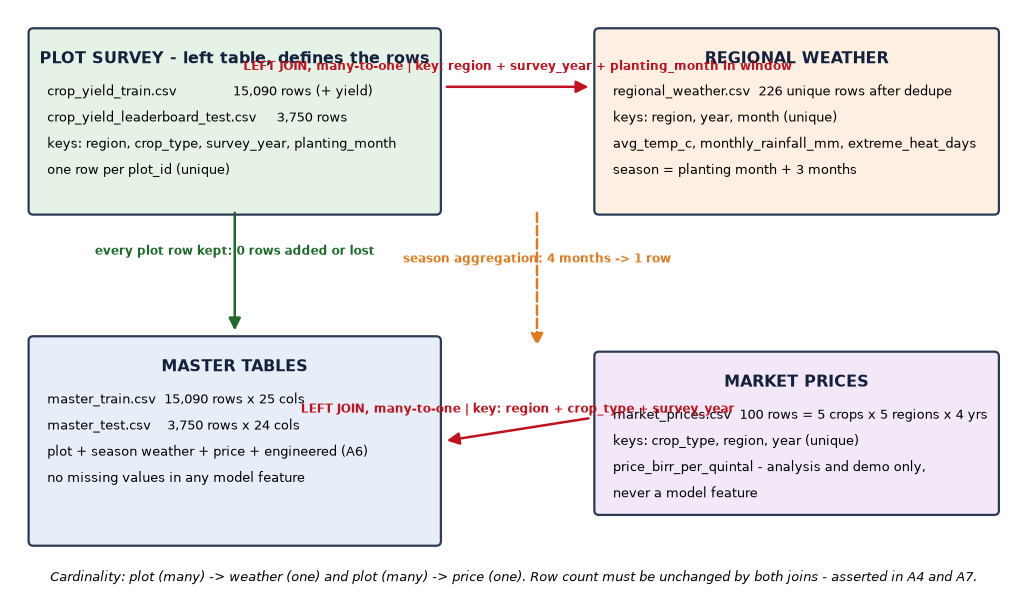

saved: reports/join_map_diagram.png


In [7]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

def draw_join_map(path="reports/join_map_diagram.png"):
    fig, ax = plt.subplots(figsize=(13, 7.6))
    ax.set_xlim(0, 13); ax.set_ylim(0, 7.6); ax.axis("off")

    def box(x, y, w, h, title, lines, fc):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06",
                                    fc=fc, ec="#2b3a55", lw=1.6))
        ax.text(x + w / 2, y + h - 0.34, title, ha="center", va="center",
                fontsize=11.5, fontweight="bold", color="#14213d")
        for i, line in enumerate(lines):
            ax.text(x + 0.18, y + h - 0.76 - i * 0.34, line, ha="left",
                    va="center", fontsize=9.2)

    def arrow(p1, p2, label, color, ls="-"):
        ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=18,
                                     color=color, lw=1.8, linestyle=ls,
                                     shrinkA=2, shrinkB=2))
        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
        ax.text(mx, my + 0.18, label, ha="center", va="bottom", fontsize=8.6,
                color=color, fontweight="bold")

    box(0.3, 5.0, 5.2, 2.3, "PLOT SURVEY - left table, defines the rows",
        ["crop_yield_train.csv              15,090 rows (+ yield)",
         "crop_yield_leaderboard_test.csv     3,750 rows",
         "keys: region, crop_type, survey_year, planting_month",
         "one row per plot_id (unique)"], "#e6f2e6")
    box(7.6, 5.0, 5.1, 2.3, "REGIONAL WEATHER",
        ["regional_weather.csv  226 unique rows after dedupe",
         "keys: region, year, month (unique)",
         "avg_temp_c, monthly_rainfall_mm, extreme_heat_days",
         "season = planting month + 3 months"], "#fdf0e3")
    box(7.6, 1.1, 5.1, 2.0, "MARKET PRICES",
        ["market_prices.csv  100 rows = 5 crops x 5 regions x 4 yrs",
         "keys: crop_type, region, year (unique)",
         "price_birr_per_quintal - analysis and demo only,",
         "never a model feature"], "#f3e8f7")
    box(0.3, 0.7, 5.2, 2.6, "MASTER TABLES",
        ["master_train.csv  15,090 rows x 25 cols",
         "master_test.csv    3,750 rows x 24 cols",
         "plot + season weather + price + engineered (A6)",
         "no missing values in any model feature"], "#e7eef7")

    arrow((5.6, 6.6), (7.5, 6.6),
          "LEFT JOIN, many-to-one | key: region + survey_year + planting_month in window",
          "#c1121f")
    arrow((6.8, 5.0), (6.8, 3.2), "season aggregation: 4 months -> 1 row", "#e07a1f", "--")
    arrow((7.5, 2.3), (5.6, 2.0),
          "LEFT JOIN, many-to-one | key: region + crop_type + survey_year", "#c1121f")
    arrow((2.9, 5.0), (2.9, 3.4), "every plot row kept: 0 rows added or lost", "#1d6a2a")

    ax.text(6.5, 0.18,
            "Cardinality: plot (many) -> weather (one) and plot (many) -> price (one). "
            "Row count must be unchanged by both joins - asserted in A4 and A7.",
            ha="center", fontsize=9.4, style="italic")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path

diagram_path = draw_join_map()
print("saved:", diagram_path)

## A4 - Join audit

For each join: match rate, row counts before and after (a many-to-one join must not change
them), unmatched plots and why, plus growing-season window coverage.

In [8]:
season_weather = ft.build_season_weather(weather_clean)
print("season-weather lookup rows:", len(season_weather),
      "= 5 regions x 4 years x 12 planting months")

n_tr, n_te = len(train_clean), len(test_clean)
train_w = ft.join_weather(train_clean, season_weather)   # validate="many_to_one" inside
test_w = ft.join_weather(test_clean, season_weather)
train_wp = ft.join_prices(train_w, prices_clean)         # same for the price join
test_wp = ft.join_prices(test_w, prices_clean)

def coverage(df):
    return {int(k): int(v) for k, v in df["wx_n_months_observed"].value_counts().sort_index().items()}

cov_tr, cov_te = coverage(train_wp), coverage(test_wp)
part_tr = sum(v for k, v in cov_tr.items() if k < 4)
part_te = sum(v for k, v in cov_te.items() if k < 4)

price_keys = set(zip(prices_clean.region, prices_clean.crop_type, prices_clean.year))
def match_rate(df):
    keys = set(zip(df.region, df.crop_type, df.survey_year))
    return 100.0 * sum(k in price_keys for k in keys) / len(keys)

n_price_blank = int(raw["prices"]["price_birr_per_quintal"].isna().sum())
dup_raw = int(raw["weather"].duplicated(subset=["region", "year", "month"]).sum())
dup_clean = int(weather_clean.duplicated(subset=["region", "year", "month"]).sum())

audit = pd.DataFrame([
    {"join": "plot -> weather (LEFT, many-to-one)",
     "join key": "region + survey_year + planting_month in season window",
     "rows before": n_tr, "rows after": len(train_w),
     "row count unchanged": len(train_w) == n_tr,
     "match rate %": round(100.0 * (train_wp.wx_n_months_observed >= 1).mean(), 2),
     "unmatched plots": int((train_wp.wx_n_months_observed < 1).sum()),
     "why / handling": "0 unmatched. " + str(part_tr) + " plots (" +
                       f"{100 * part_tr / n_tr:.1f}%) have <4 observed months; missing months are " +
                       "filled from the region-month climatology and flagged in wx_n_months_observed"},
    {"join": "plot -> weather (LEFT, many-to-one)",
     "join key": "region + survey_year + planting_month in season window",
     "rows before": n_te, "rows after": len(test_w),
     "row count unchanged": len(test_w) == n_te,
     "match rate %": round(100.0 * (test_wp.wx_n_months_observed >= 1).mean(), 2),
     "unmatched plots": int((test_wp.wx_n_months_observed < 1).sum()),
     "why / handling": "0 unmatched. " + str(part_te) + " plots (" +
                       f"{100 * part_te / n_te:.1f}%) have <4 observed months - same handling as train"},
    {"join": "plot -> price (LEFT, many-to-one)",
     "join key": "region + crop_type + survey_year",
     "rows before": n_tr, "rows after": len(train_wp),
     "row count unchanged": len(train_wp) == n_tr,
     "match rate %": round(match_rate(train_wp), 2), "unmatched plots": 0,
     "why / handling": "every crop-region-year key exists in the 100-row price grid; " +
                       f"{n_price_blank} blank prices filled with the crop x region mean"},
    {"join": "plot -> price (LEFT, many-to-one)",
     "join key": "region + crop_type + survey_year",
     "rows before": n_te, "rows after": len(test_wp),
     "row count unchanged": len(test_wp) == n_te,
     "match rate %": round(match_rate(test_wp), 2), "unmatched plots": 0,
     "why / handling": "all keys matched; blank prices filled exactly as for train"},
])
print(f"duplicate weather keys: raw {dup_raw} -> cleaned {dup_clean}")
print("growing-season coverage  train:", cov_tr, " test:", cov_te)
print(f"plots with a partial window: train {part_tr:,} ({100 * part_tr / n_tr:.1f}%), "
      f"test {part_te:,} ({100 * part_te / n_te:.1f}%)")
assert len(train_w) == n_tr and len(test_w) == n_te
assert len(train_wp) == n_tr and len(test_wp) == n_te
print("A4 PASS - both joins left the row counts unchanged")
audit

season-weather lookup rows: 240 = 5 regions x 4 years x 12 planting months


duplicate weather keys: raw 6 -> cleaned 0
growing-season coverage  train: {2: 448, 3: 2477, 4: 12165}  test: {2: 113, 3: 635, 4: 3002}
plots with a partial window: train 2,925 (19.4%), test 748 (19.9%)
A4 PASS - both joins left the row counts unchanged


,join,join key,rows before,rows after,row count unchanged,match rate %,unmatched plots,why / handling
0,"plot -> weather (LEFT, many-to-one)",region + survey_year + planting_month in seaso...,15090,15090,True,100.0,0,0 unmatched. 2925 plots (19.4%) have <4 observ...
1,"plot -> weather (LEFT, many-to-one)",region + survey_year + planting_month in seaso...,3750,3750,True,100.0,0,0 unmatched. 748 plots (19.9%) have <4 observe...
2,"plot -> price (LEFT, many-to-one)",region + crop_type + survey_year,15090,15090,True,100.0,0,every crop-region-year key exists in the 100-r...
3,"plot -> price (LEFT, many-to-one)",region + crop_type + survey_year,3750,3750,True,100.0,0,all keys matched; blank prices filled exactly ...


## A5 - Join proof: 3 specific plots

For three real plots: which weather rows the join pulled for its growing-season window
(planting month + 3 months), and the season-level numbers they produced. The numbers are then
recomputed by hand from the cleaned weather table and compared with what is stored in the master.

In [9]:
# Build the master tables in memory (exported to CSV in A8)
from src.features import build_data_dictionary

master_train = ft.add_engineered_features(train_wp)
master_test = ft.add_engineered_features(test_wp)
master_train = master_train[list(master_test.columns) + ["yield_tons_per_ha"]]
print("master_train:", master_train.shape, " master_test:", master_test.shape)

master_train: (15090, 25)  master_test: (3750, 24)


In [10]:
clim = weather_clean.groupby(["region", "month"], as_index=False).agg(
    clim_temp=("avg_temp_c", "mean"), clim_rain=("monthly_rainfall_mm", "mean"))

def prove_join(plot_id):
    row = master_train.loc[master_train.plot_id == plot_id].iloc[0]
    win = ft.season_window(int(row.survey_year), row.planting_month)
    w_idx = weather_clean.set_index(["region", "year", "month"])
    rows = []
    for (y, m) in win:
        if (row.region, y, m) in w_idx.index:
            r = w_idx.loc[(row.region, y, m)]
            rows.append({"region": row.region, "year": y, "month": m,
                         "source": "weather table", "avg_temp_c": r["avg_temp_c"],
                         "monthly_rainfall_mm": r["monthly_rainfall_mm"],
                         "extreme_heat_days": r["extreme_heat_days"]})
        else:
            c = clim[(clim.region == row.region) & (clim.month == m)].iloc[0]
            rows.append({"region": row.region, "year": y, "month": m,
                         "source": "MISSING -> region-month climatology",
                         "avg_temp_c": c["clim_temp"],
                         "monthly_rainfall_mm": c["clim_rain"], "extreme_heat_days": 0})
    pulled = pd.DataFrame(rows)
    manual = {"wx_season_mean_temp_c": pulled.avg_temp_c.mean(),
              "wx_season_rain_total_mm": pulled.monthly_rainfall_mm.sum(),
              "wx_extreme_heat_days": int(pulled.extreme_heat_days.sum()),
              "wx_n_months_observed": int((pulled.source == "weather table").sum())}
    stored = {k: row[k] for k in manual}
    ok = all(abs(float(manual[k]) - float(stored[k])) < 0.06 for k in manual)
    print("=" * 104)
    print(f"{plot_id} | {row.region} | {row.crop_type} | {int(row.survey_year)} | "
          f"planted {row.planting_month} | window {win}")
    print(pulled.to_string(index=False))
    print("hand-computed :", {k: round(float(v), 3) for k, v in manual.items()})
    print("stored master :", {k: round(float(v), 3) for k, v in stored.items()})
    print("MATCH" if ok else "*** MISMATCH ***")
    return ok

cases = [
    master_train.loc[master_train.wx_n_months_observed == 4, "plot_id"].iloc[0],
    master_train.loc[master_train.wx_n_months_observed < 4, "plot_id"].iloc[0],
    master_train.loc[(master_train.planting_month == "Feb")
                     & (master_train.wx_n_months_observed == 4), "plot_id"].iloc[0],
]
proof_ok = [prove_join(pid) for pid in cases]
assert all(proof_ok), "A5 join proof failed"
print()
print("A5 PASS - all three plots reproduce their stored season features by hand")

PLOT-007457 | Amhara | maize | 2023 | planted Jun | window [(2023, 'Jun'), (2023, 'Jul'), (2023, 'Aug'), (2023, 'Sep')]
region  year month        source  avg_temp_c  monthly_rainfall_mm  extreme_heat_days
Amhara  2023   Jun weather table        17.0                118.5                0.0
Amhara  2023   Jul weather table        14.9                244.6                0.0
Amhara  2023   Aug weather table        14.5                192.8                0.0
Amhara  2023   Sep weather table        14.4                153.5                0.0
hand-computed : {'wx_season_mean_temp_c': 15.2, 'wx_season_rain_total_mm': 709.4, 'wx_extreme_heat_days': 0.0, 'wx_n_months_observed': 4.0}
stored master : {'wx_season_mean_temp_c': 15.2, 'wx_season_rain_total_mm': 709.4, 'wx_extreme_heat_days': 0.0, 'wx_n_months_observed': 4.0}
MATCH
PLOT-000339 | Oromia | barley | 2024 | planted Aug | window [(2024, 'Aug'), (2024, 'Sep'), (2024, 'Oct'), (2024, 'Nov')]
region  year month                              

## A6 - Feature engineering table

Eight engineered features: six are derived from the weather table (requirement: at least 3),
one is an interaction and one comes from `planting_month`.

In [11]:
feature_table = pd.DataFrame([
    ("wx_season_mean_temp_c", "weather", "mean(avg_temp_c) over planting month + 3 months",
     "regional_weather.avg_temp_c + plot region/survey_year/planting_month",
     "every crop has a temperature optimum and the plot table has no temperature at all"),
    ("wx_season_rain_total_mm", "weather", "sum(monthly_rainfall_mm) over the same 4 months",
     "regional_weather.monthly_rainfall_mm",
     "station rainfall is measured, while the plot's own rainfall is self-reported and noisy"),
    ("wx_extreme_heat_days", "weather", "sum(extreme_heat_days) over the window",
     "regional_weather.extreme_heat_days",
     "heat spikes during flowering cut yields, especially maize and teff"),
    ("wx_temp_anomaly_c", "weather",
     "season mean temp - the region's own typical temp for those calendar months",
     "regional_weather.avg_temp_c",
     "an unusually hot year in a hot region is what hurts, not the absolute level"),
    ("wx_n_months_observed", "weather", "count of window months present in the weather table (0-4)",
     "weather key presence",
     "flags seasons built partly from climatology so the model can discount them"),
    ("rain_gap_mm", "weather + plot", "rainfall_mm_season - wx_season_rain_total_mm",
     "plot rainfall_mm_season, weather aggregate",
     "farmer-reported vs station-measured disagreement marks atypical or misreported plots"),
    ("fert_x_seed", "interaction", "fertilizer_kg_per_ha * improved_seed_used",
     "fertilizer_kg_per_ha, improved_seed_used",
     "fertilizer pays off mainly with improved seed - an additive model cannot express that"),
    ("planting_month_num", "planting month", "planting_month mapped to 1-12",
     "planting_month",
     "timing moves the season into different rainfall and heat regimes; gives an ordered month"),
], columns=["feature", "type", "formula", "source columns", "why we expect it to help"])
print(f"{len(feature_table)} engineered features | "
      f"{int(feature_table.type.str.contains('weather').sum())} weather-derived (>=3 required) | "
      f"{int((feature_table.type == 'interaction').sum())} interaction | "
      f"{int((feature_table.type == 'planting month').sum())} from planting_month")
feature_table

8 engineered features | 6 weather-derived (>=3 required) | 1 interaction | 1 from planting_month


,feature,type,formula,source columns,why we expect it to help
0,wx_season_mean_temp_c,weather,mean(avg_temp_c) over planting month + 3 months,regional_weather.avg_temp_c + plot region/surv...,every crop has a temperature optimum and the p...
1,wx_season_rain_total_mm,weather,sum(monthly_rainfall_mm) over the same 4 months,regional_weather.monthly_rainfall_mm,"station rainfall is measured, while the plot's..."
2,wx_extreme_heat_days,weather,sum(extreme_heat_days) over the window,regional_weather.extreme_heat_days,"heat spikes during flowering cut yields, espec..."
3,wx_temp_anomaly_c,weather,season mean temp - the region's own typical te...,regional_weather.avg_temp_c,an unusually hot year in a hot region is what ...
4,wx_n_months_observed,weather,count of window months present in the weather ...,weather key presence,flags seasons built partly from climatology so...
5,rain_gap_mm,weather + plot,rainfall_mm_season - wx_season_rain_total_mm,"plot rainfall_mm_season, weather aggregate",farmer-reported vs station-measured disagreeme...
6,fert_x_seed,interaction,fertilizer_kg_per_ha * improved_seed_used,"fertilizer_kg_per_ha, improved_seed_used",fertilizer pays off mainly with improved seed ...
7,planting_month_num,planting month,planting_month mapped to 1-12,planting_month,timing moves the season into different rainfal...


In [12]:
eng = list(feature_table.feature)
master_train[["plot_id", "region", "crop_type", "planting_month"] + eng].head(8)

,plot_id,region,crop_type,planting_month,wx_season_mean_temp_c,wx_season_rain_total_mm,wx_extreme_heat_days,wx_temp_anomaly_c,wx_n_months_observed,rain_gap_mm,fert_x_seed,planting_month_num
0,PLOT-000339,Oromia,barley,Aug,18.492,375.1,0,-0.294,3,782.30,0.0000,8
1,PLOT-007457,Amhara,maize,Jun,15.200,709.4,0,-0.674,4,188.02,16.8440,6
2,PLOT-006092,Oromia,wheat,Feb,19.200,294.9,0,-0.869,4,824.26,0.0000,2
3,PLOT-004128,SNNPR,barley,Aug,19.425,398.3,1,-0.400,4,848.16,0.0000,8
4,PLOT-003033,Amhara,sorghum,Jul,16.500,798.2,1,0.414,4,130.28,33.7361,7
5,PLOT-005025,Amhara,sorghum,Feb,15.825,229.8,0,-1.938,4,459.62,0.0000,2
6,PLOT-012687,Somali,sorghum,Jul,29.675,162.4,65,1.975,4,990.30,0.0000,7
7,PLOT-007887,Tigray,sorghum,Jul,16.188,493.7,0,-0.488,3,-72.97,0.0000,7


## A7 - Integrity checks (automated, printed PASS/FAIL)

In [13]:
check_rows = []
def check(name, condition, detail=""):
    status = "PASS" if bool(condition) else "FAIL"
    check_rows.append({"#": len(check_rows) + 1, "check": name,
                       "result": status, "detail": detail})
    print(f"{status}  {name}  {detail}")

REG, CRP = set(cl.REGIONS), set(cl.CROPS)
nan_tr = int(master_train[ft.MODEL_FEATURES].isna().sum().sum())
nan_te = int(master_test[ft.MODEL_FEATURES].isna().sum().sum())

check("plot_id is unique in master_train", master_train.plot_id.is_unique, f"n={len(master_train)}")
check("plot_id is unique in master_test", master_test.plot_id.is_unique, f"n={len(master_test)}")
check("row count unchanged by the joins (train)", len(master_train) == len(raw["train"]),
      f"{len(raw['train'])} -> {len(master_train)}")
check("row count unchanged by the joins (test)", len(master_test) == len(raw["test"]),
      f"{len(raw['test'])} -> {len(master_test)}")
check("no missing values in model features (train)", nan_tr == 0, f"NaNs={nan_tr}")
check("no missing values in model features (test)", nan_te == 0, f"NaNs={nan_te}")
check("region labels within the allowed set (all 3 files)",
      set(master_train.region) <= REG and set(master_test.region) <= REG
      and set(weather_clean.region) <= REG and set(prices_clean.region) <= REG, str(sorted(REG)))
check("crop labels within the allowed set (plot + price)",
      set(master_train.crop_type) <= CRP and set(master_test.crop_type) <= CRP
      and set(prices_clean.crop_type) <= CRP, str(sorted(CRP)))
check("train and test share the same feature columns (minus target)",
      [c for c in master_train.columns if c != "yield_tons_per_ha"] == list(master_test.columns),
      f"{master_test.shape[1]} cols")
check("yield >= 0 (train target)", float(master_train.yield_tons_per_ha.min()) >= 0,
      f"min={master_train.yield_tons_per_ha.min():.3f}")
check("price > 0 in both masters",
      master_train.price_birr_per_quintal.min() > 0 and master_test.price_birr_per_quintal.min() > 0,
      f"min={master_train.price_birr_per_quintal.min():.1f}")
check("soil_quality_index inside [0, 1]",
      master_train.soil_quality_index.between(0, 1).all()
      and master_test.soil_quality_index.between(0, 1).all())
check("weather key (region, year, month) unique after cleaning",
      not weather_clean.duplicated(["region", "year", "month"]).any(), f"rows={len(weather_clean)}")
check("price key (crop, region, year) unique after cleaning",
      not prices_clean.duplicated(["crop_type", "region", "year"]).any(), f"rows={len(prices_clean)}")
check("no -999 sentinels left in either master",
      not (master_train.select_dtypes("number") == -999).any().any()
      and not (master_test.select_dtypes("number") == -999).any().any())
check("price is NOT a model feature (analysis only)",
      "price_birr_per_quintal" not in ft.MODEL_FEATURES)
check("at least one weather-derived feature is used (Rule 5)",
      len([f for f in ft.WEATHER_FEATURES if f in ft.MODEL_FEATURES]) >= 1,
      f"{len(ft.WEATHER_FEATURES)} weather features in the model")

checks_df = pd.DataFrame(check_rows)
print()
print(f"{(checks_df.result == 'PASS').sum()}/{len(checks_df)} checks PASS")
assert (checks_df.result == "PASS").all(), "integrity checks failed"

PASS  plot_id is unique in master_train  n=15090
PASS  plot_id is unique in master_test  n=3750
PASS  row count unchanged by the joins (train)  15090 -> 15090
PASS  row count unchanged by the joins (test)  3750 -> 3750
PASS  no missing values in model features (train)  NaNs=0
PASS  no missing values in model features (test)  NaNs=0
PASS  region labels within the allowed set (all 3 files)  ['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']
PASS  crop labels within the allowed set (plot + price)  ['barley', 'maize', 'sorghum', 'teff', 'wheat']
PASS  train and test share the same feature columns (minus target)  24 cols
PASS  yield >= 0 (train target)  min=0.100
PASS  price > 0 in both masters  min=2403.0
PASS  soil_quality_index inside [0, 1]  
PASS  weather key (region, year, month) unique after cleaning  rows=226
PASS  price key (crop, region, year) unique after cleaning  rows=100
PASS  no -999 sentinels left in either master  
PASS  price is NOT a model feature (analysis only)  
PASS  a

## A8 - Master tables, data dictionary and demo lookup tables

In [14]:
Path("data/processed").mkdir(parents=True, exist_ok=True)
master_train.to_csv("data/processed/master_train.csv", index=False)
master_test.to_csv("data/processed/master_test.csv", index=False)

data_dictionary = build_data_dictionary(master_train)
data_dictionary.to_csv("data/processed/data_dictionary_master.csv", index=False)

# lookup tables bundled with the demo (Deliverable E) - no weather typing needed there
Path("app/assets").mkdir(parents=True, exist_ok=True)
season_weather.to_csv("app/assets/season_weather.csv", index=False)
prices_clean.to_csv("app/assets/prices_clean.csv", index=False)
(master_train.groupby(["region", "survey_year", "planting_month"], as_index=False)
 ["rainfall_mm_season"].median()
 .rename(columns={"rainfall_mm_season": "plot_rain_median_mm"})
 .to_csv("app/assets/plot_rain_lookup.csv", index=False))

print("data/processed/master_train.csv         ", master_train.shape)
print("data/processed/master_test.csv          ", master_test.shape)
print("data/processed/data_dictionary_master.csv", data_dictionary.shape)
print("app/assets/{season_weather, prices_clean, plot_rain_lookup}.csv written")
print("columns identical apart from the target:",
      [c for c in master_train.columns if c != "yield_tons_per_ha"] == list(master_test.columns))
data_dictionary.head(30)

data/processed/master_train.csv          (15090, 25)
data/processed/master_test.csv           (3750, 24)
data/processed/data_dictionary_master.csv (25, 6)
app/assets/{season_weather, prices_clean, plot_rain_lookup}.csv written
columns identical apart from the target: True


,column,dtype,source_file,description,derivation,used_as_model_feature
0,plot_id,str,crop_yield_*.csv,Unique plot ID / join key for scoring,as given,no
1,region,object,crop_yield_*.csv + regional_weather.csv,Ethiopian region of the plot,label standardisation (alias map),yes
2,crop_type,string,crop_yield_*.csv + market_prices.csv,Crop grown,label standardisation (alias map),yes
3,survey_year,int64,crop_yield_*.csv,Survey / season year 2021-2024,"as given, integer",yes
4,planting_month,object,crop_yield_*.csv,Month the crop was planted,label standardisation,yes
5,altitude_m,float64,crop_yield_*.csv,"Plot elevation, metres above sea level",as given,yes
6,rainfall_mm_season,float64,crop_yield_*.csv,"Plot self-reported growing-season rainfall, mm",median-imputed (train median); capped at train...,yes
7,farm_size_ha,float64,crop_yield_*.csv,"Farm size, hectares",capped at train p99.5,yes
8,fertilizer_kg_per_ha,float64,crop_yield_*.csv,"Fertilizer applied, kg/ha",median-imputed; capped at train p99.5,yes
9,improved_seed_used,int64,crop_yield_*.csv,Certified improved seed (0/1),"as given, integer",yes


## Write `reports/A_cleaning_and_integration.md`

In [15]:
NL = chr(10)
header = """# A - Data Cleaning & Integration Pipeline

**Team Adwa** - Qiyas / IADE Hackathon, Addis Ababa University (5 October 2026)

Generated by `notebooks/01_cleaning_and_integration.ipynb`. Every number below is produced by code
in this project. Raw inputs (never edited): crop_yield_train.csv (15,090 rows),
crop_yield_leaderboard_test.csv (3,750), regional_weather.csv (232), market_prices.csv (100).
"""

p = []
def block(title, *chunks):
    """Add one report section: heading + markdown chunks."""
    p.append(NL + "## " + title + NL + NL)
    for c in chunks:
        p.append(c if c.endswith(NL) else c + NL)

block("A1 - Cleaning log", cleaning_log.to_markdown(index=False))
p.append(NL + "**Statistics fit on the train file only and applied unchanged to the test file "
              "(Rule 6):**" + NL + NL + stats_table.to_markdown(index=False) + NL)
p.append(NL + f"{len(cleaning_log)} issue rows over 3 files: plot train {len(log_train)}, plot test "
              f"{len(log_test)}, weather {len(log_weather)}, prices {len(log_prices)} - at least 4 "
              "distinct issues in the plot file, 3 in the weather file, 3 in the price file." + NL)

block("A2 - Key standardisation proof", key_proof.to_markdown(index=False))
p.append(NL + "Assertions printed by the notebook: region labels are identical across plot train, "
              "plot test, weather and price tables; crop labels are identical across plot train, "
              "plot test and price tables." + NL)

block("A3 - Join map & diagram", "![Join map](join_map_diagram.png)", """
- **Growing-season window:** planting month + the following three months (rolls into the next
  calendar year if needed). Monthly weather is aggregated to one row per
  `(region, survey_year, planting_month)` before any plot joins it.
- **plot -> weather:** LEFT join on `region + survey_year + planting_month`, many-to-one.
- **plot -> price:** LEFT join on `region + crop_type + survey_year`, many-to-one.
- **Why the plot table is the left table:** the leaderboard scores every test plot, so the plot
  table defines the row set; weather and price are attributes of a plot's region-year and can only
  add columns, never rows.
""")

block("A4 - Join audit", audit.to_markdown(index=False), f"""
- Row counts: train {n_tr:,} -> {len(train_w):,} -> {len(train_wp):,}; test {n_te:,} ->
  {len(test_w):,} -> {len(test_wp):,}. Unchanged by both joins; `validate="many_to_one"` is asserted
  inside the join helpers, so a duplicate key raises instead of silently duplicating plots.
- Duplicate weather keys before the join: {dup_raw} duplicated rows over
  {len(raw['weather']) - len(weather_clean)} keys - averaged away, leaving {dup_clean}.
- Season coverage: train {cov_tr}, test {cov_te}. {part_tr:,} train plots
  ({100 * part_tr / n_tr:.1f}%) and {part_te:,} test plots ({100 * part_te / n_te:.1f}%) have fewer
  than the full four months.
- Handling: missing months are filled from that region's month climatology (mean of the same
  calendar month over the available years) and `wx_n_months_observed` records how many months were
  real, so the model can discount partly-imputed seasons.
- Unmatched plots: weather 0 / 0 and price 0 / 0. {n_price_blank} blank prices were filled with the
  crop x region mean.
""")

block("A5 - Join proof (3 plots)",
      "For each plot the notebook prints its four window months, the weather rows pulled (or the "
      "climatology used when a month is missing), the hand-computed season aggregates and the stored "
      "master values. Plots proven: " + ", ".join("`" + x + "`" for x in cases) + " - all MATCH.")

block("A6 - Feature engineering table", feature_table.to_markdown(index=False),
      "Six of the eight features come from the weather table (Rule 5); `fert_x_seed` is the "
      "interaction and `planting_month_num` comes from planting_month.")

block("A7 - Integrity checks", checks_df.to_markdown(index=False),
      f"**{(checks_df.result == 'PASS').sum()}/{len(checks_df)} checks PASS.** The notebook prints "
      "one PASS/FAIL line per check.")

block("A8 - Master tables & data dictionary",
      "| file | rows | columns |" + NL + "|---|---|---|" + NL +
      f"| data/processed/master_train.csv | {len(master_train):,} | {master_train.shape[1]} |" + NL +
      f"| data/processed/master_test.csv | {len(master_test):,} | {master_test.shape[1]} |" + NL +
      f"| data/processed/data_dictionary_master.csv | {len(data_dictionary):,} | "
      f"{data_dictionary.shape[1]} |",
      "master_test has exactly the master_train columns minus the target. Label repair is "
      "deterministic; imputation values and outlier caps are fit on the train file only and then "
      "applied to test, so nothing is learned from the test data (Rule 6).",
      data_dictionary.to_markdown(index=False))

report_path = Path("reports/A_cleaning_and_integration.md")
report_path.write_text(header + "".join(p), encoding="utf-8")
print("wrote", report_path, "(", report_path.stat().st_size, "bytes )")

wrote reports\A_cleaning_and_integration.md ( 37954 bytes )
